In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/Mall_Customers.csv")

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
df.shape

(200, 5)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [4]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


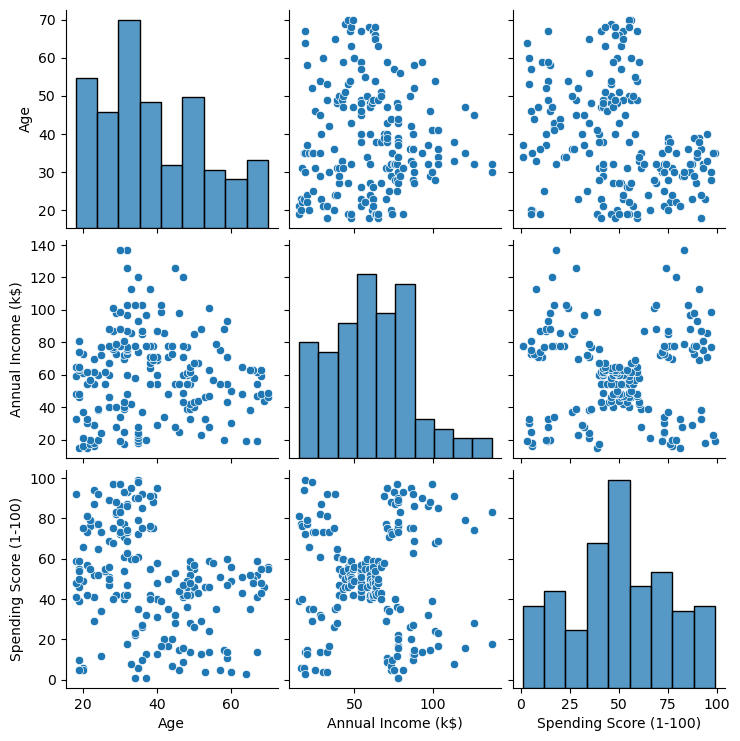

In [6]:
sns.pairplot(
    df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]
)

plt.show()

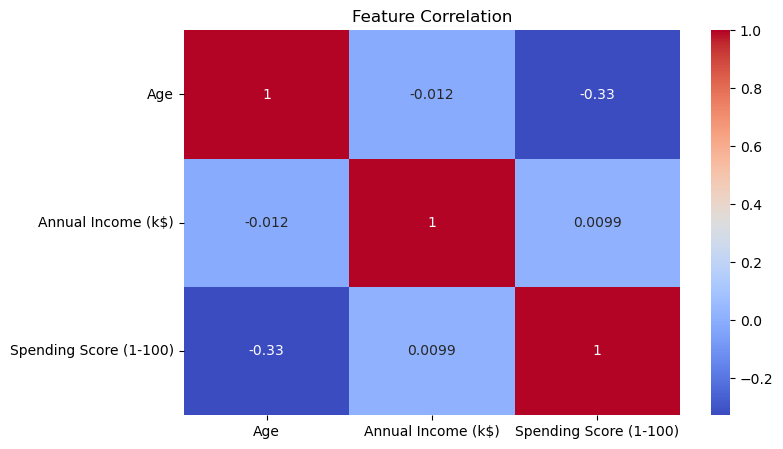

In [7]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")
plt.show()

In [8]:
df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].corr()

,Age,Annual Income (k$),Spending Score (1-100)
Age,1.000000,-0.012398,-0.327227
Annual Income (k$),-0.012398,1.000000,0.009903
Spending Score (1-100),-0.327227,0.009903,1.000000


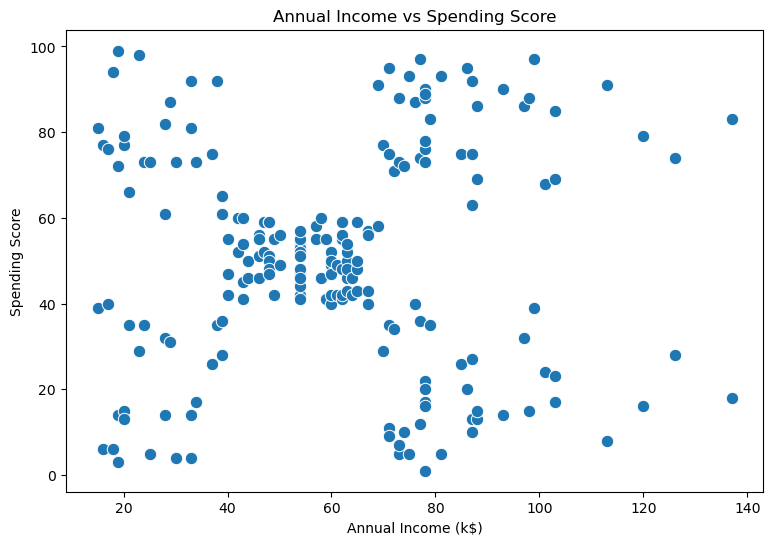

In [9]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    s=80
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.show()

In [10]:
from sklearn.preprocessing import StandardScaler

features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df[features])

X_scaled[:5]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

In [11]:
X_scaled.mean(axis=0)

array([-1.02140518e-16, -2.13162821e-16, -1.46549439e-16])

In [12]:
X_scaled.std(axis=0)

array([1., 1., 1.])

In [13]:
from sklearn.cluster import KMeans

inertias = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertias.append(kmeans.inertia_)

c:\Users\ZoRo\anaconda3\envs\venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ZoRo\anaconda3\envs\venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ZoRo\anaconda3\envs\venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ZoRo\anaconda3\envs\venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is k

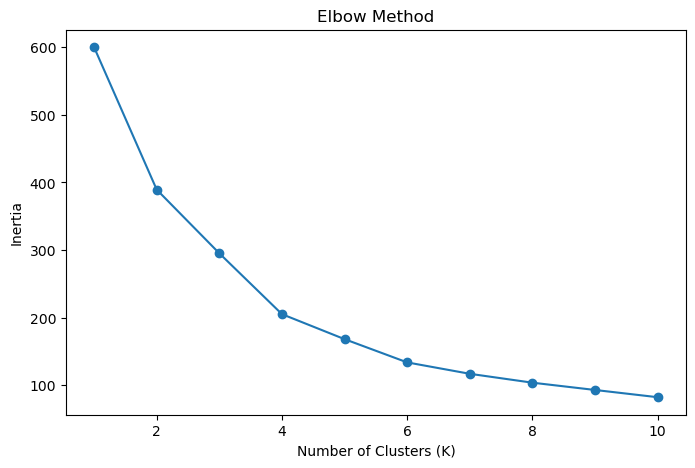

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [15]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

c:\Users\ZoRo\anaconda3\envs\venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [16]:
df["Cluster"].value_counts().sort_index()

Cluster
0    65
1    40
2    57
3    38
Name: count, dtype: int64

In [17]:
cluster_centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)

cluster_summary = pd.DataFrame(
    cluster_centers,
    columns=features
)

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
0,53.984615,47.707692,39.969231
1,32.875000,86.100000,81.525000
2,25.438596,40.000000,60.298246
3,39.368421,86.500000,19.578947


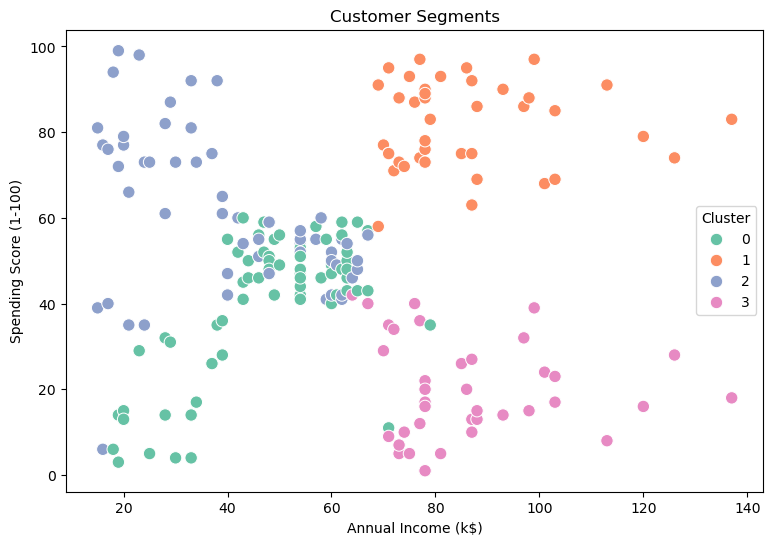

In [18]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set2",
    s=80
)

plt.title("Customer Segments")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")

plt.show()

In [19]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(
    X_scaled,
    clusters
)

silhouette

0.4039582785148566

In [20]:
silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

c:\Users\ZoRo\anaconda3\envs\venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ZoRo\anaconda3\envs\venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ZoRo\anaconda3\envs\venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ZoRo\anaconda3\envs\venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is k

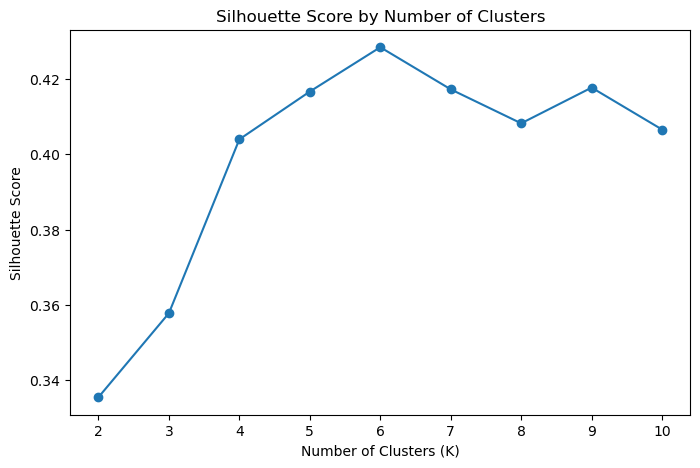

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")

plt.show()

In [22]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

X_pca.shape

(200, 2)

In [23]:
pca.explained_variance_ratio_

array([0.44266167, 0.33308378])

In [24]:
pca.explained_variance_ratio_.sum()

np.float64(0.7757454566976747)

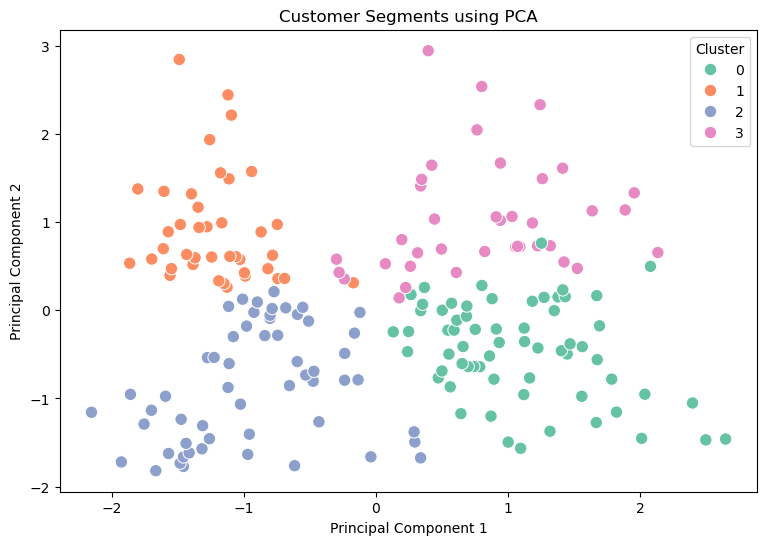

In [25]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df["Cluster"],
    palette="Set2",
    s=80
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments using PCA")
plt.legend(title="Cluster")

plt.show()

In [26]:
pca_components = pd.DataFrame(
    pca.components_,
    columns=features,
    index=["PC1", "PC2"]
)

pca_components

,Age,Annual Income (k$),Spending Score (1-100)
PC1,0.706382,-0.048024,-0.706199
PC2,0.030141,0.998832,-0.037775


In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

X = df[features]


# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Train K-Means
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

c:\Users\ZoRo\anaconda3\envs\venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,4
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [28]:
import joblib

joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(kmeans, "../models/kmeans.pkl")

['../models/kmeans.pkl']

In [31]:
dict(zip(range(2, 11), silhouette_scores))

{2: 0.33547192894004574,
 3: 0.357793388710272,
 4: 0.4039582785148566,
 5: 0.41664341513732767,
 6: 0.4284167762892593,
 7: 0.417231894954916,
 8: 0.4082067042807375,
 9: 0.41769250624076476,
 10: 0.40655411010117015}

In [32]:
silhouette_results = pd.DataFrame({
    "K": range(2, 11),
    "Silhouette Score": silhouette_scores
})

silhouette_results

,K,Silhouette Score
0,2,0.335472
1,3,0.357793
2,4,0.403958
3,5,0.416643
4,6,0.428417
5,7,0.417232
6,8,0.408207
7,9,0.417693
8,10,0.406554
